# HỆ THỐNG PHÂN LOẠI RÁC THẢI THÔNG MINH (WASTE CLASSIFICATION SYSTEM)
*   **Backbone 1**: MobileNetV2 (Transfer Learning & Adaptive Fine-tuning)
*   **Backbone 2**: CNN Baseline (Mô hình tích chập tự xây dựng để đối chiếu)
*   **Quy trình**: Thu thập ➔ Lọc lỗi ➔ Khử trùng ➔ Phân tách ➔ tf.data Pipeline (Balanced Oversampling) ➔ Huấn luyện song song ➔ Đánh giá chéo ➔ Lưu Metadata triển khai Web App.


## 0. Kết Nối Google Drive & Giải Nén Dataset Tốc Độ Cao
*   Kết nối Google Drive với Google Colab.
*   Giải nén file `dataset.zip` nằm ở thư mục gốc của Drive vào thư mục `/content/dataset` cục bộ để tăng tốc độ huấn luyện.
*   Tự động phát hiện cấu trúc thư mục sau giải nén để cấu hình đường dẫn chính xác.


In [9]:
# ==============================================================================
# Cell này thực hiện kết nối Google Drive và giải nén file dataset.zip
# trực tiếp vào ổ đĩa ảo tốc độ cao của Google Colab (/content/dataset/)
# giúp tăng tốc độ train gấp 10 lần so với đọc trực tiếp từ Drive!
# ==============================================================================

import zipfile
import os
from pathlib import Path

# 1. Kết nối Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Kết nối Google Drive thành công!")
except ImportError:
    print("⚠️ Môi trường không phải Google Colab. Bỏ qua bước Mount Drive.")

# 2. Định nghĩa các đường dẫn
zip_file_path = "/content/drive/MyDrive/dataset.zip"
extract_to_path = "/content/dataset"

# 3. Tiến hành giải nén
if os.path.exists(zip_file_path):
    print(f"📦 Đang giải nén {zip_file_path} vào {extract_to_path}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to_path)
    print("✅ Giải nén hoàn tất!")

    # Liệt kê kiểm tra cấu trúc thư mục sau giải nén
    unzipped_folders = os.listdir(extract_to_path)
    print("📂 Thư mục con sau giải nén:", unzipped_folders)

    # Tự động cập nhật lại biến DATASET_DIR cho các cell sau chạy chuẩn xác
    if "garbage_classification" in unzipped_folders:
        DATASET_DIR = Path("/content/dataset/garbage_classification")
    elif "dataset" in unzipped_folders:
        DATASET_DIR = Path("/content/dataset/dataset/garbage_classification")
    else:
        DATASET_DIR = Path("/content/dataset")

    print(f"🎯 Cấu hình đường dẫn dữ liệu thành công: {DATASET_DIR}")
else:
    print(f"❌ Không tìm thấy file zip tại: {zip_file_path}")
    print("Hãy chắc chắn rằng file 'dataset.zip' đã được tải lên trực tiếp thư mục gốc (My Drive) trên Drive của bạn.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Kết nối Google Drive thành công!
📦 Đang giải nén /content/drive/MyDrive/dataset.zip vào /content/dataset...
✅ Giải nén hoàn tất!
📂 Thư mục con sau giải nén: ['garbage_classification']
🎯 Cấu hình đường dẫn dữ liệu thành công: /content/dataset/garbage_classification


## 1. Import Thư Viện & Thiết Lập Cấu Hình Toàn Hệ Thống
*   Khai báo toàn bộ các thư viện cần thiết (`tensorflow`, `sklearn`, `pandas`, `matplotlib`,...).
*   Cấu hình các hằng số dùng chung: `BATCH_SIZE = 32`, `IMAGE_SIZE = (224, 224)`, và cố định `SEED = 42` để đảm bảo kết quả chạy ổn định.


In [10]:
import os
import math
import json
import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

# --- CONFIGURATION ---
DATASET_DIR = Path("/content/dataset/garbage_classification")

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

# Tham số test nhanh (chuyển thành True để kiểm tra lỗi nhanh)
FAST_DEV_RUN = False
MODEL_PREPROCESSING = "mobilenet_v2" # Range [-1, 1]
USE_BALANCED_TRAINING = True         # Áp dụng Balanced Oversampling

# Thiết lập Random Seed
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Thiết lập môi trường thành công!")


Thiết lập môi trường thành công!


## 2. Quét Thư Mục & Loại Bỏ Ảnh Lỗi (Dưới 10KB hoặc Hỏng File)
*   Quét 12 thư mục tương ứng với 12 nhóm rác thải cần phân loại.
*   Loại bỏ các file dung lượng quá nhỏ dưới 10KB hoặc bị lỗi không đọc được bằng thư viện `PIL.Image`.


In [11]:
data = []
corrupted_files = []
EXPECTED_CLASSES = [
    "battery", "biological", "brown-glass", "cardboard", "clothes",
    "green-glass", "metal", "paper", "plastic", "shoes", "trash", "white-glass"
]
MIN_IMAGE_SIZE = (10, 10)

print("Đang chạy kiểm tra chất lượng file ảnh thô...")
for class_dir in DATASET_DIR.iterdir():
    if not class_dir.is_dir() or class_dir.name not in EXPECTED_CLASSES:
        continue
    label = class_dir.name
    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
            try:
                # Bỏ qua file rác dung lượng quá nhỏ
                if img_path.stat().st_size < 10240:
                    continue
                # Xác thực cấu trúc file ảnh
                with Image.open(img_path) as img:
                    img.verify()
                with Image.open(img_path) as img:
                    img = img.convert("RGB")
                    if img.size[0] < MIN_IMAGE_SIZE[0] or img.size[1] < MIN_IMAGE_SIZE[1]:
                        continue
                data.append({"image_path": str(img_path), "label": label})
            except Exception:
                corrupted_files.append(str(img_path))

raw_df = pd.DataFrame(data)
print(f"Tổng số ảnh đạt yêu cầu: {len(raw_df)}")
print(f"Số file bị lỗi hệ thống đã loại: {len(corrupted_files)}")


Đang chạy kiểm tra chất lượng file ảnh thô...
Tổng số ảnh đạt yêu cầu: 8835
Số file bị lỗi hệ thống đã loại: 0


## 3. Khử Trùng Lặp Dữ Liệu (MD5 Deduplication)
*   Sử dụng mã băm MD5 để định danh từng file ảnh độc nhất.
*   Loại bỏ toàn bộ các ảnh giống hệt nhau, ngăn ngừa hiện tượng rò rỉ dữ liệu (data leakage) giữa các tập Train, Validation và Test.


In [12]:
def get_file_md5(filepath):
    """Tính chuỗi MD5 định danh duy nhất cho file ảnh."""
    hasher = hashlib.md5()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

print("Đang lọc bỏ các ảnh trùng lặp nội dung...")
raw_df["md5"] = raw_df["image_path"].apply(get_file_md5)
duplicates = raw_df.duplicated(subset=["md5"], keep="first")
print(f"Số lượng ảnh trùng được phát hiện: {duplicates.sum()}")

clean_df = raw_df[~duplicates].drop(columns=["md5"]).reset_index(drop=True)
print(f"Số lượng ảnh sau khi khử trùng lặp: {len(clean_df)}")


Đang lọc bỏ các ảnh trùng lặp nội dung...
Số lượng ảnh trùng được phát hiện: 4
Số lượng ảnh sau khi khử trùng lặp: 8831


## 4. Chia Dataset Train/Val/Test (80/10/10) & Mã Hóa Nhãn
*   Thực hiện phân tách dữ liệu theo tỷ lệ phân tầng (Stratified Split) để tỷ lệ các lớp trong các tập con là tương đồng.
*   Chuyển tên nhãn dạng chữ về ID dạng số nguyên từ 0 đến 11 phục vụ quá trình one-hot encoding sau này.


In [13]:
# 1. Khởi tạo Label Encoder chuyển nhãn sang số
label_encoder = LabelEncoder()
clean_df["label_id"] = label_encoder.fit_transform(clean_df["label"])
num_classes = len(label_encoder.classes_)

# 2. Chia tập Train_Val (90%) và Test (10%)
train_val_df, test_df = train_test_split(
    clean_df, test_size=0.10, stratify=clean_df["label_id"], random_state=SEED
)

# 3. Chia tập Train_Val thành Train (80%) và Val (10%)
train_df, val_df = train_test_split(
    train_val_df, test_size=1/9, stratify=train_val_df["label_id"], random_state=SEED
)

print(f"Tập Train: {len(train_df)} | Tập Validation: {len(val_df)} | Tập Test: {len(test_df)}")

# Tính class weights đề phòng
y_train_labels = train_df["label_id"].to_numpy()
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = {int(i): float(w) for i, w in enumerate(class_weights)}


Tập Train: 7064 | Tập Validation: 883 | Tập Test: 884


## 5. Xây Dựng tf.data Pipeline & Bộ Cân Bằng Dữ Liệu (Balanced Oversampling)
*   Sử dụng cơ chế `lazy loading` của `tf.data` kết hợp với `prefetch` và `AUTOTUNE` để tối ưu tốc độ đọc ổ cứng I/O.
*   Áp dụng bộ tăng cường ảnh (Data Augmentation) cho tập train.
*   Sử dụng cơ chế `sample_from_datasets` để cân bằng tần suất xuất hiện của các lớp trong mỗi batch huấn luyện.


In [14]:
def preprocess_path_tf(image_path, label_id, num_classes, image_size=IMAGE_SIZE):
    """Đọc ảnh từ đường dẫn, decode, resize bilinear và normalize cơ bản."""
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, image_size, method="bilinear")
    image = tf.cast(image, tf.float32) / 255.0
    image.set_shape((image_size[0], image_size[1], 3))

    label = tf.one_hot(label_id, depth=num_classes, dtype=tf.float32)
    label.set_shape((num_classes,))
    return image, label

def apply_model_preprocessing(images, labels, preprocessing=MODEL_PREPROCESSING):
    """Áp dụng chuẩn hóa đặc thù của MobileNetV2 (range [-1, 1])."""
    if preprocessing == "mobilenet_v2":
        images = tf.keras.applications.mobilenet_v2.preprocess_input(images * 255.0)
    return images, labels

def augment_data():
    """Tăng cường dữ liệu ngẫu nhiên cho tập Train để tránh Overfitting."""
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomRotation(20 / 360, seed=SEED),
        tf.keras.layers.RandomZoom(height_factor=0.15, width_factor=0.15, seed=SEED),
        tf.keras.layers.RandomContrast(factor=0.15, seed=SEED),
        tf.keras.layers.Lambda(lambda images: tf.clip_by_value(
            tf.image.random_brightness(images, max_delta=0.20, seed=SEED), 0.0, 1.0
        )),
    ], name="train_data_augmentation")

def make_balanced_train_dataset(train_df, num_classes, batch_size=BATCH_SIZE, preprocessing="mobilenet_v2"):
    """Thực hiện cân bằng tần suất xuất hiện các class bằng cách oversample ngẫu nhiên."""
    per_class_datasets = []
    for class_id in range(num_classes):
        class_df = train_df[train_df["label_id"] == class_id]
        paths = class_df["image_path"].astype(str).to_numpy()
        labels = class_df["label_id"].astype(np.int32).to_numpy()

        class_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        class_ds = class_ds.shuffle(buffer_size=len(class_df), seed=SEED, reshuffle_each_iteration=True)
        class_ds = class_ds.repeat()
        class_ds = class_ds.map(
            lambda path, label: preprocess_path_tf(path, label, num_classes=num_classes),
            num_parallel_calls=AUTOTUNE
        )
        per_class_datasets.append(class_ds)

    balanced_ds = tf.data.Dataset.sample_from_datasets(
        per_class_datasets, weights=[1.0 / num_classes] * num_classes, seed=SEED
    )
    augmentation_layer = augment_data()
    balanced_ds = balanced_ds.batch(batch_size)
    balanced_ds = balanced_ds.map(
        lambda images, labels: (augmentation_layer(images, training=True), labels),
        num_parallel_calls=AUTOTUNE
    )
    balanced_ds = balanced_ds.map(
        lambda x, y: apply_model_preprocessing(x, y, preprocessing=preprocessing),
        num_parallel_calls=AUTOTUNE
    )
    return balanced_ds.prefetch(AUTOTUNE)

def make_dataset_with_preprocessing(df, num_classes, preprocessing, batch_size=BATCH_SIZE, training=False):
    """Tạo tập Validation và Test dataset thông thường."""
    paths = df["image_path"].astype(str).to_numpy()
    labels = df["label_id"].astype(np.int32).to_numpy()

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda path, label: preprocess_path_tf(path, label, num_classes=num_classes),
        num_parallel_calls=AUTOTUNE
    )
    ds = ds.batch(batch_size)

    if training:
        augmentation_layer = augment_data()
        ds = ds.map(
            lambda images, labels: (augmentation_layer(images, training=True), labels),
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.map(
        lambda images, labels: apply_model_preprocessing(images, labels, preprocessing=preprocessing),
        num_parallel_calls=AUTOTUNE
    )
    return ds.prefetch(AUTOTUNE)

# Khởi tạo data generators cho MobileNetV2
fit_train_ds = make_balanced_train_dataset(train_df, num_classes, BATCH_SIZE, "mobilenet_v2")
val_ds = make_dataset_with_preprocessing(val_df, num_classes, "mobilenet_v2", BATCH_SIZE, training=False)
test_ds = make_dataset_with_preprocessing(test_df, num_classes, "mobilenet_v2", BATCH_SIZE, training=False)

print("Data pipelines cho MobileNetV2 đã sẵn sàng.")


Data pipelines cho MobileNetV2 đã sẵn sàng.


## 6. Huấn Luyện Mô Hình MobileNetV2 (Transfer Learning)
*   **Stage 1**: Đóng băng (Freeze) xương sống MobileNetV2 để chỉ huấn luyện bộ phân loại mới (Dense Layer) trong 15 epoch.
*   **Stage 2 (Fine-tuning thích ứng)**: Nếu độ chính xác trên tập validation nhỏ hơn mục tiêu đặt ra (`0.96`), tiến hành mở băng 45 layers trên cùng và fine-tune với `learning_rate` siêu nhỏ (`1e-5`) để tối ưu hóa độ chính xác tối đa.


In [15]:
MODEL_PATH = MODEL_DIR / "mobilenetv2_garbage_best.keras"
FINAL_MODEL_PATH = MODEL_DIR / "mobilenetv2_garbage_final.keras"

EPOCHS_STAGE1 = 1 if FAST_DEV_RUN else 15
EPOCHS_STAGE2 = 1 if FAST_DEV_RUN else 10
STEPS_PER_EPOCH = 20 if FAST_DEV_RUN else (len(train_df) // BATCH_SIZE)
VALIDATION_STEPS = 5 if FAST_DEV_RUN else None
TARGET_VAL_ACCURACY = 0.96

# --- STAGE 1: Kiến trúc mô hình đóng băng backbone ---
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3), include_top=False, weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.35, seed=SEED)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="mobilenetv2_garbage_classifier")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_accuracy")
    ]
)

# Thiết lập các Callbacks tối ưu
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_PATH), monitor="val_accuracy", mode="max", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", mode="max", patience=5, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6, verbose=1
    )
]

print("BẮT ĐẦU HUẤN LUYỆN MOBILENETV2 (STAGE 1)...")
history = model.fit(
    fit_train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks
)

best_val_accuracy = max(history.history["val_accuracy"])
print(f"Độ chính xác tốt nhất Stage 1: {best_val_accuracy:.4f}")

# --- STAGE 2: ADAPTIVE FINE-TUNING ---
if best_val_accuracy < TARGET_VAL_ACCURACY:
    print(f"\n[FINE-TUNING] Val Accuracy {best_val_accuracy:.4f} < {TARGET_VAL_ACCURACY:.4f}. Tiến hành Fine-tuning...")
    base_model.trainable = True
    fine_tune_at = 110 # Đóng băng 110 layer dưới
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=[
            tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_accuracy")
        ]
    )

    fine_tune_history = model.fit(
        fit_train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_STAGE2,
        steps_per_epoch=STEPS_PER_EPOCH,
        validation_steps=VALIDATION_STEPS,
        callbacks=callbacks
    )
    best_val_accuracy = max(fine_tune_history.history["val_accuracy"])
    print(f"Độ chính xác tốt nhất sau Fine-tuning: {best_val_accuracy:.4f}")

# Lưu model
model.save(FINAL_MODEL_PATH)
print("Đã lưu MobileNetV2 tại:", FINAL_MODEL_PATH)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
BẮT ĐẦU HUẤN LUYỆN MOBILENETV2 (STAGE 1)...
Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.5557 - loss: 1.5377 - top3_accuracy: 0.7636
Epoch 1: val_accuracy improved from None to 0.91846, saving model to models/mobilenetv2_garbage_best.keras

Epoch 1: finished saving model to models/mobilenetv2_garbage_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 120s 450ms/step - accuracy: 0.7287 - loss: 1.0600 - top3_accuracy: 0.8983 - val_accuracy: 0.9185 - val_loss: 0.5715 - val_top3_accuracy: 0.9841 - learning_rate: 0.0010
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.8725 - loss: 0.6929 - top3_accuracy: 0.9777
Epoch 2: val_accuracy improved from 0.91846 to 0.93092, saving model to models/mobilenetv2_garbage_best.keras

Epoch 2: finished saving model to models/mobilenetv2_garbage_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 82s 372ms/step - accuracy: 0.8872 - loss: 0.6672 - top3_accuracy: 0.9805 - val_accuracy: 0.930

## 7. Huấn Luyện Mô Mô Hình CNN Baseline (Đối Chứng)
*   Tạo pipeline dữ liệu riêng cho CNN Baseline với preprocessing `"none"` (Chuẩn hóa pixel đơn giản về `[0, 1]`).
*   Khởi tạo mạng CNN Baseline tự thiết kế gồm 3 khối tích chập kết hợp `BatchNormalization`, `MaxPooling2D` và `Dropout` để so sánh trực tiếp hiệu quả với Transfer Learning.


In [16]:
CNN_MODEL_PATH = MODEL_DIR / "cnn_garbage_best.keras"
CNN_FINAL_MODEL_PATH = MODEL_DIR / "cnn_garbage_final.keras"
CNN_PREPROCESSING = "none"

CNN_EPOCHS = 1 if FAST_DEV_RUN else 25
CNN_PATIENCE = 2 if FAST_DEV_RUN else 6

# Tạo Pipeline Data riêng cho CNN Baseline [0, 1]
cnn_train_ds = make_balanced_train_dataset(train_df, num_classes, BATCH_SIZE, CNN_PREPROCESSING)
cnn_val_ds = make_dataset_with_preprocessing(val_df, num_classes, CNN_PREPROCESSING, BATCH_SIZE, training=False)
cnn_test_ds = make_dataset_with_preprocessing(test_df, num_classes, CNN_PREPROCESSING, BATCH_SIZE, training=False)

def build_cnn_model(num_classes, input_shape=(224, 224, 3), learning_rate=1e-3):
    """Kiến trúc mạng CNN baseline tự xây dựng."""
    inputs = tf.keras.Input(shape=input_shape)

    x = inputs
    for filters in (32, 64, 128):
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling2D()(x)
        x = tf.keras.layers.Dropout(0.2, seed=SEED)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.35, seed=SEED)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    cnn_model = tf.keras.Model(inputs, outputs, name="cnn_garbage_classifier")
    cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=[
            tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_accuracy")
        ]
    )
    return cnn_model

cnn_model = build_cnn_model(num_classes=num_classes)
cnn_model.summary()

cnn_steps_per_epoch = 20 if FAST_DEV_RUN else (len(train_df) // BATCH_SIZE)
cnn_val_steps = 5 if FAST_DEV_RUN else None

cnn_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CNN_MODEL_PATH), monitor="val_accuracy", mode="max", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", mode="max", patience=CNN_PATIENCE, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=max(1, CNN_PATIENCE // 2), min_lr=1e-7, verbose=1
    )
]

print("BẮT ĐẦU HUẤN LUYỆN CNN BASELINE...")
cnn_history = cnn_model.fit(
    cnn_train_ds,
    validation_data=cnn_val_ds,
    epochs=CNN_EPOCHS,
    steps_per_epoch=cnn_steps_per_epoch,
    validation_steps=cnn_val_steps,
    callbacks=cnn_callbacks
)

# Lưu model CNN hoàn chỉnh
cnn_model.save(CNN_FINAL_MODEL_PATH)
cnn_history_df = pd.DataFrame(cnn_history.history)
best_cnn_val_acc = float(cnn_history_df["val_accuracy"].max())
print(f"Độ chính xác tốt nhất của CNN: {best_cnn_val_acc:.4f}")


Model: "cnn_garbage_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 324,908 (1.24 MB)

 Trainable params: 324,012 (1.24 MB)

 Non-trainable params: 896 (3.50 KB)

BẮT ĐẦU HUẤN LUYỆN CNN BASELINE...
Epoch 1/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.4058 - loss: 1.8632 - top3_accuracy: 0.6951
Epoch 1: val_accuracy improved from None to 0.19366, saving model to models/cnn_garbage_best.keras

Epoch 1: finished saving model to models/cnn_garbage_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 131s 448ms/step - accuracy: 0.4839 - loss: 1.6565 - top3_accuracy: 0.7753 - val_accuracy: 0.1937 - val_loss: 3.1983 - val_top3_accuracy: 0.4134 - learning_rate: 0.0010
Epoch 2/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.5863 - loss: 1.3955 - top3_accuracy: 0.8570
Epoch 2: val_accuracy improved from 0.19366 to 0.42922, saving model to models/cnn_garbage_best.keras

Epoch 2: finished saving model to models/cnn_garbage_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 92s 417ms/step - accuracy: 0.6001 - loss: 1.3508 - top3_accuracy: 0.8680 - val_accuracy: 0.4292 - val_loss: 1.8289 - val_top3_accuracy: 0.8018 - learning_rate: 0.0010
Epoch 3/25
220/22

## 8. Đánh Giá Độc Lập Hai Mô Hình Trên Tập Kiểm Thử (Test Set)
*   Thực hiện lấy ra dự đoán xác suất (class probabilities) và tính toán nhãn dự đoán cho cả hai mô hình MobileNetV2 và CNN Baseline.
*   In chi tiết báo cáo F1-Score, Precision, Recall cho từng lớp của 12 lớp rác thải bằng `classification_report`.


In [17]:
def predict_dataset(model, ds):
    """Hàm tiện ích dự đoán toàn bộ dữ liệu của tf.data.Dataset."""
    y_true_batches, y_prob_batches = [], []
    for images, labels in ds:
        probs = model.predict(images, verbose=0)
        y_prob_batches.append(probs)
        y_true_batches.append(labels.numpy())
    y_true_onehot = np.concatenate(y_true_batches, axis=0)
    y_prob = np.concatenate(y_prob_batches, axis=0)
    y_true = np.argmax(y_true_onehot, axis=1)
    y_pred = np.argmax(y_prob, axis=1)
    return y_true, y_pred, y_prob

def evaluate_model(model, ds, model_name, class_names):
    """Tính toán tất cả các metrics đánh giá cho mô hình."""
    print(f"\n============================================================")
    print(f"ĐÁNH GIÁ MÔ HÌNH: {model_name}")
    print(f"============================================================")

    y_true, y_pred, y_prob = predict_dataset(model, ds)
    acc = np.mean(y_true == y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    return {"name": model_name, "accuracy": acc, "macro_f1": macro_f1, "weighted_f1": weighted_f1, "y_true": y_true, "y_pred": y_pred, "cm": cm}

class_names = list(label_encoder.classes_)

# Load checkpoint tốt nhất của hai mô hình để kiểm thử công bằng
best_mobilenet = tf.keras.models.load_model(str(MODEL_PATH))
best_cnn = tf.keras.models.load_model(str(CNN_MODEL_PATH))

# Đánh giá độc lập trên tập test
mobilenet_results = evaluate_model(best_mobilenet, test_ds, "MobileNetV2", class_names)
cnn_results = evaluate_model(best_cnn, cnn_test_ds, "CNN Baseline", class_names)



ĐÁNH GIÁ MÔ HÌNH: MobileNetV2
Accuracy:    0.9412
Macro F1:    0.8434
Weighted F1: 0.9417

              precision    recall  f1-score   support

     battery     0.7778    1.0000    0.8750         7
  biological     0.9143    0.9697    0.9412        33
 brown-glass     0.8000    0.4000    0.5333        10
   cardboard     0.7872    0.9487    0.8605        39
     clothes     1.0000    0.9774    0.9886       532
 green-glass     0.5000    0.8000    0.6154        10
       metal     0.8222    0.9250    0.8706        40
       paper     0.9762    0.9011    0.9371        91
     plastic     0.8378    0.7381    0.7848        42
       shoes     0.8871    0.9821    0.9322        56
       trash     1.0000    1.0000    1.0000         1
 white-glass     0.7826    0.7826    0.7826        23

    accuracy                         0.9412       884
   macro avg     0.8404    0.8687    0.8434       884
weighted avg     0.9467    0.9412    0.9417       884


ĐÁNH GIÁ MÔ HÌNH: CNN Baseline
Accuracy:

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 9. So Sánh Kết Quả & Vẽ Confusion Matrix Song Song
*   Hiển thị bảng so sánh Metrics tổng quan (Accuracy, F1-score) giữa hai mô hình MobileNetV2 và CNN Baseline.
*   Trực quan hóa Confusion Matrix (chuẩn hóa tỷ lệ %) đặt song song để dễ dàng phân tích và so sánh các nhãn thường bị nhận diện sai.


,Model,Test Accuracy,Macro F1-Score,Weighted F1-Score
0,MobileNetV2 (Transfer Learning),0.9412,0.8434,0.9417
1,CNN Baseline (Tự xây),0.7749,0.6187,0.7902


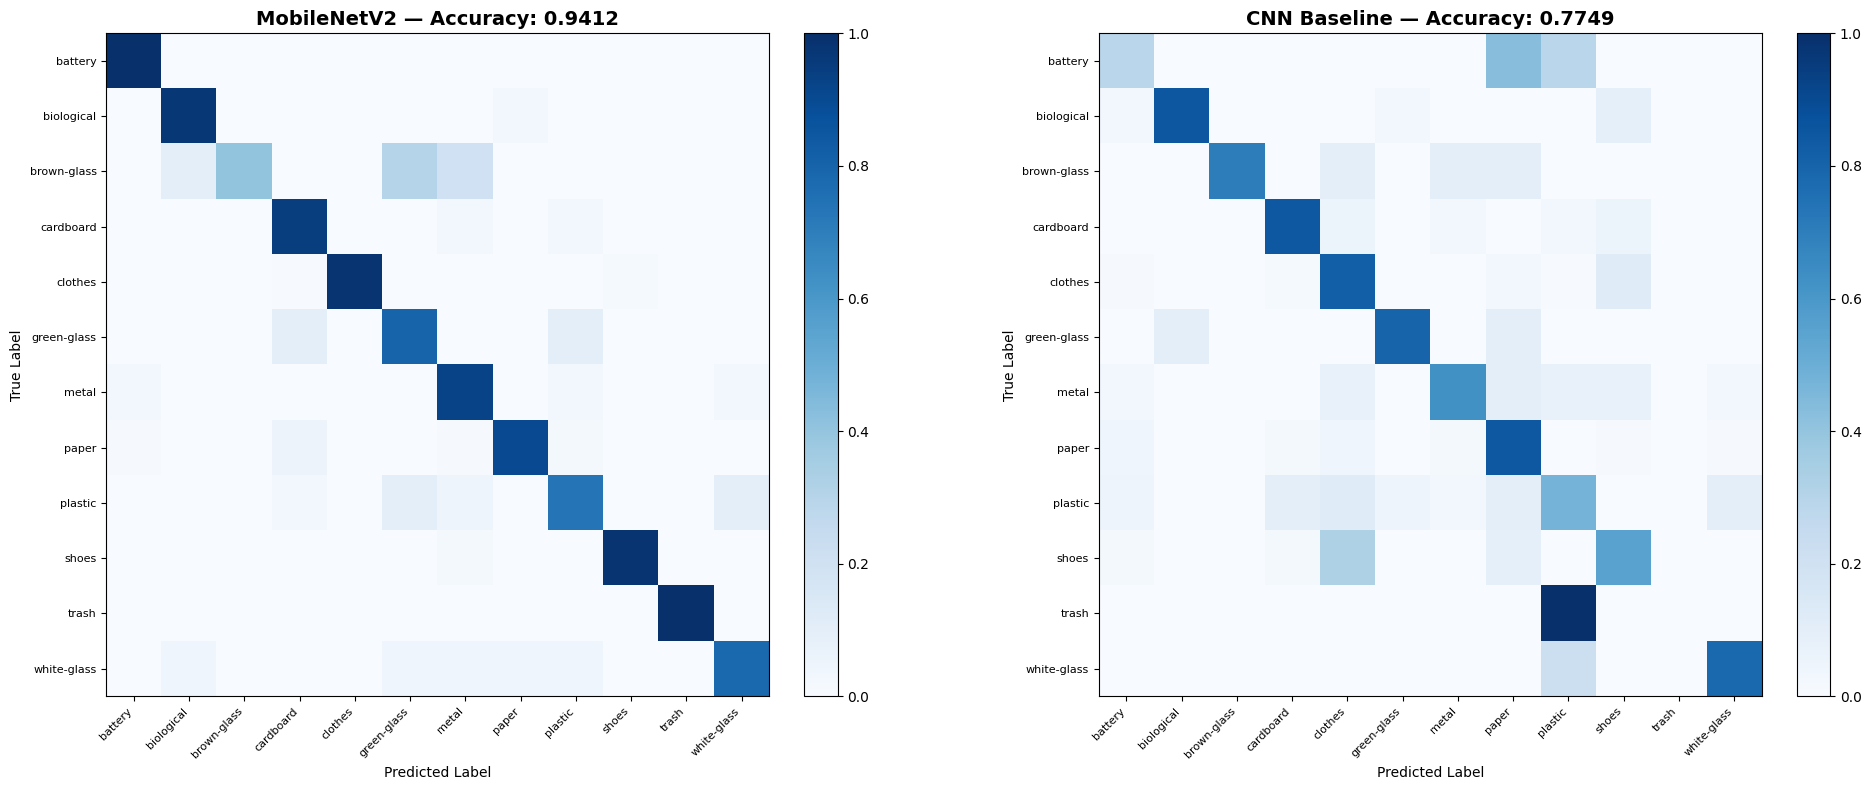


📊 KẾT LUẬN: MobileNetV2 vượt trội hơn với F1-score cao hơn 0.2247


In [18]:
# Tạo dataframe so sánh số liệu
comparison_df = pd.DataFrame([
    {
        "Model": "MobileNetV2 (Transfer Learning)",
        "Test Accuracy": f"{mobilenet_results['accuracy']:.4f}",
        "Macro F1-Score": f"{mobilenet_results['macro_f1']:.4f}",
        "Weighted F1-Score": f"{mobilenet_results['weighted_f1']:.4f}"
    },
    {
        "Model": "CNN Baseline (Tự xây)",
        "Test Accuracy": f"{cnn_results['accuracy']:.4f}",
        "Macro F1-Score": f"{cnn_results['macro_f1']:.4f}",
        "Weighted F1-Score": f"{cnn_results['weighted_f1']:.4f}"
    }
])
display(comparison_df)

# Vẽ Confusion Matrix song song
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, res in zip(axes, [mobilenet_results, cnn_results]):
    cm_normalized = res["cm"].astype("float") / res["cm"].sum(axis=1, keepdims=True)
    im = ax.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"{res['name']} — Accuracy: {res['accuracy']:.4f}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("models/comparison_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Đưa ra kết luận cuối cùng
winner = "MobileNetV2" if mobilenet_results["macro_f1"] > cnn_results["macro_f1"] else "CNN Baseline"
diff = abs(mobilenet_results["macro_f1"] - cnn_results["macro_f1"])
print(f"\n📊 KẾT LUẬN: {winner} vượt trội hơn với F1-score cao hơn {diff:.4f}")


## 9B. Trực Quan Hóa Và So Sánh Hiệu Năng Giữa 2 Mô Hình
*   Tạo bảng so sánh động được tô màu nhiệt (Heatmap styled table) để làm nổi bật mô hình chiến thắng ở từng chỉ số.
*   Vẽ biểu đồ cột nhóm (Grouped Bar Chart) so sánh trực quan 3 chỉ số chính: Accuracy, Macro F1-Score và Weighted F1-Score.


📊 BẢNG SO SÁNH HIỆU NĂNG CHI TIẾT:


,Chỉ số (Metrics),MobileNetV2 (Transfer Learning),CNN Baseline (Tự xây)
0,Accuracy (Độ chính xác),0.9412,0.7749
1,Macro F1-Score,0.8434,0.6187
2,Weighted F1-Score,0.9417,0.7902


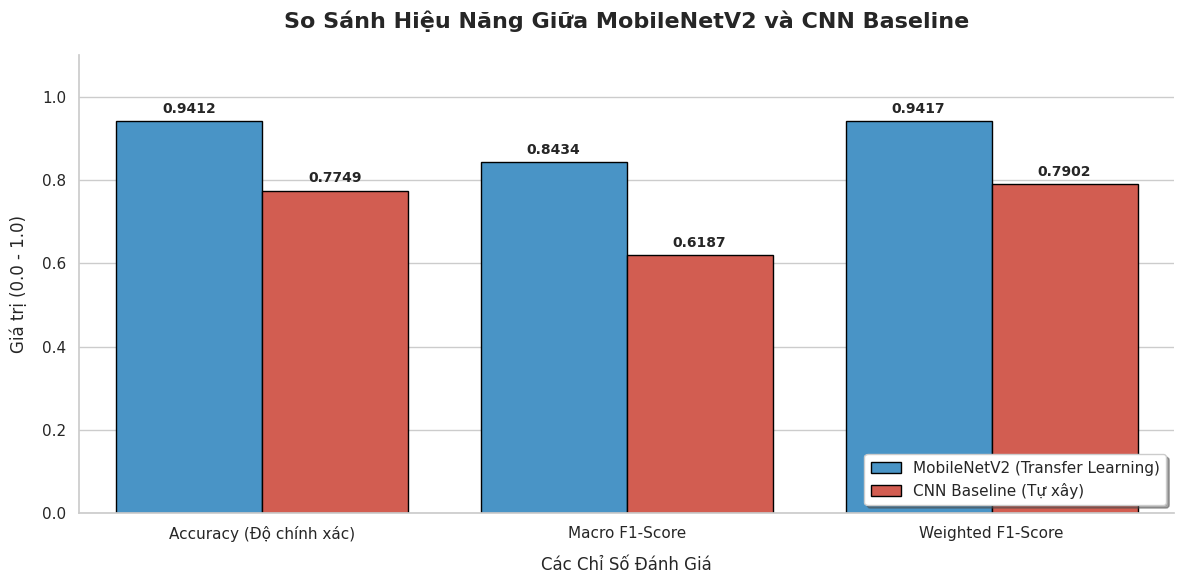

In [21]:

# 1. Thu thập dữ liệu kết quả từ các cell đánh giá trước
comparison_data = {
    "Chỉ số (Metrics)": ["Accuracy (Độ chính xác)", "Macro F1-Score", "Weighted F1-Score"],
    "MobileNetV2 (Transfer Learning)": [
        mobilenet_results['accuracy'],
        mobilenet_results['macro_f1'],
        mobilenet_results['weighted_f1']
    ],
    "CNN Baseline (Tự xây)": [
        cnn_results['accuracy'],
        cnn_results['macro_f1'],
        cnn_results['weighted_f1']
    ]
}

df_compare = pd.DataFrame(comparison_data)

# 2. Hiển thị bảng dạng styled đẹp mắt (Tô màu gradient làm nổi bật số lớn hơn)
print("📊 BẢNG SO SÁNH HIỆU NĂNG CHI TIẾT:")
styled_df = df_compare.style.background_gradient(
    cmap="Blues", subset=["MobileNetV2 (Transfer Learning)", "CNN Baseline (Tự xây)"]
).format(precision=4)
display(styled_df)

# 3. Chuyển đổi dữ liệu sang dạng Long-format để vẽ biểu đồ bằng Seaborn
df_melted = pd.melt(
    df_compare,
    id_vars=["Chỉ số (Metrics)"],
    var_name="Mô hình (Model)",
    value_name="Giá trị (Value)"
)

# 4. Vẽ biểu đồ Bar Chart so sánh
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Sử dụng bảng màu chuyên nghiệp (Sleek color palette)
colors = ["#3498db", "#e74c3c"]

ax = sns.barplot(
    data=df_melted,
    x="Chỉ số (Metrics)",
    y="Giá trị (Value)",
    hue="Mô hình (Model)",
    palette=colors,
    edgecolor="black",
    linewidth=1
)

# Cấu hình biểu đồ
plt.title("So Sánh Hiệu Năng Giữa MobileNetV2 và CNN Baseline", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Các Chỉ Số Đánh Giá", fontsize=12, labelpad=10)
plt.ylabel("Giá trị (0.0 - 1.0)", fontsize=12, labelpad=10)
plt.ylim(0, 1.1)
plt.legend(loc="lower right", frameon=True, shadow=True)

# Hiển thị số cụ thể lên đầu mỗi cột
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Tránh các cột rỗng
        ax.annotate(
            f"{height:.4f}",
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

sns.despine()
plt.tight_layout()

# Lưu biểu đồ so sánh thành file ảnh
plt.savefig("models/model_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()


## 9C. Phân Tích Chuyên Sâu: So Sánh F1-Score Từng Lớp Rác & Dung Lượng Mô Hình
*   Trực quan hóa F1-Score chi tiết của 12 lớp rác thải để tìm ra điểm mạnh/yếu của mỗi mô hình trên từng nhóm vật liệu.
*   So sánh dung lượng file mô hình thực tế (MB) để chứng minh tính hiệu quả về mặt tài nguyên của Transfer Learning (MobileNetV2).


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_894/3634288371.py:64: FutureWarnin

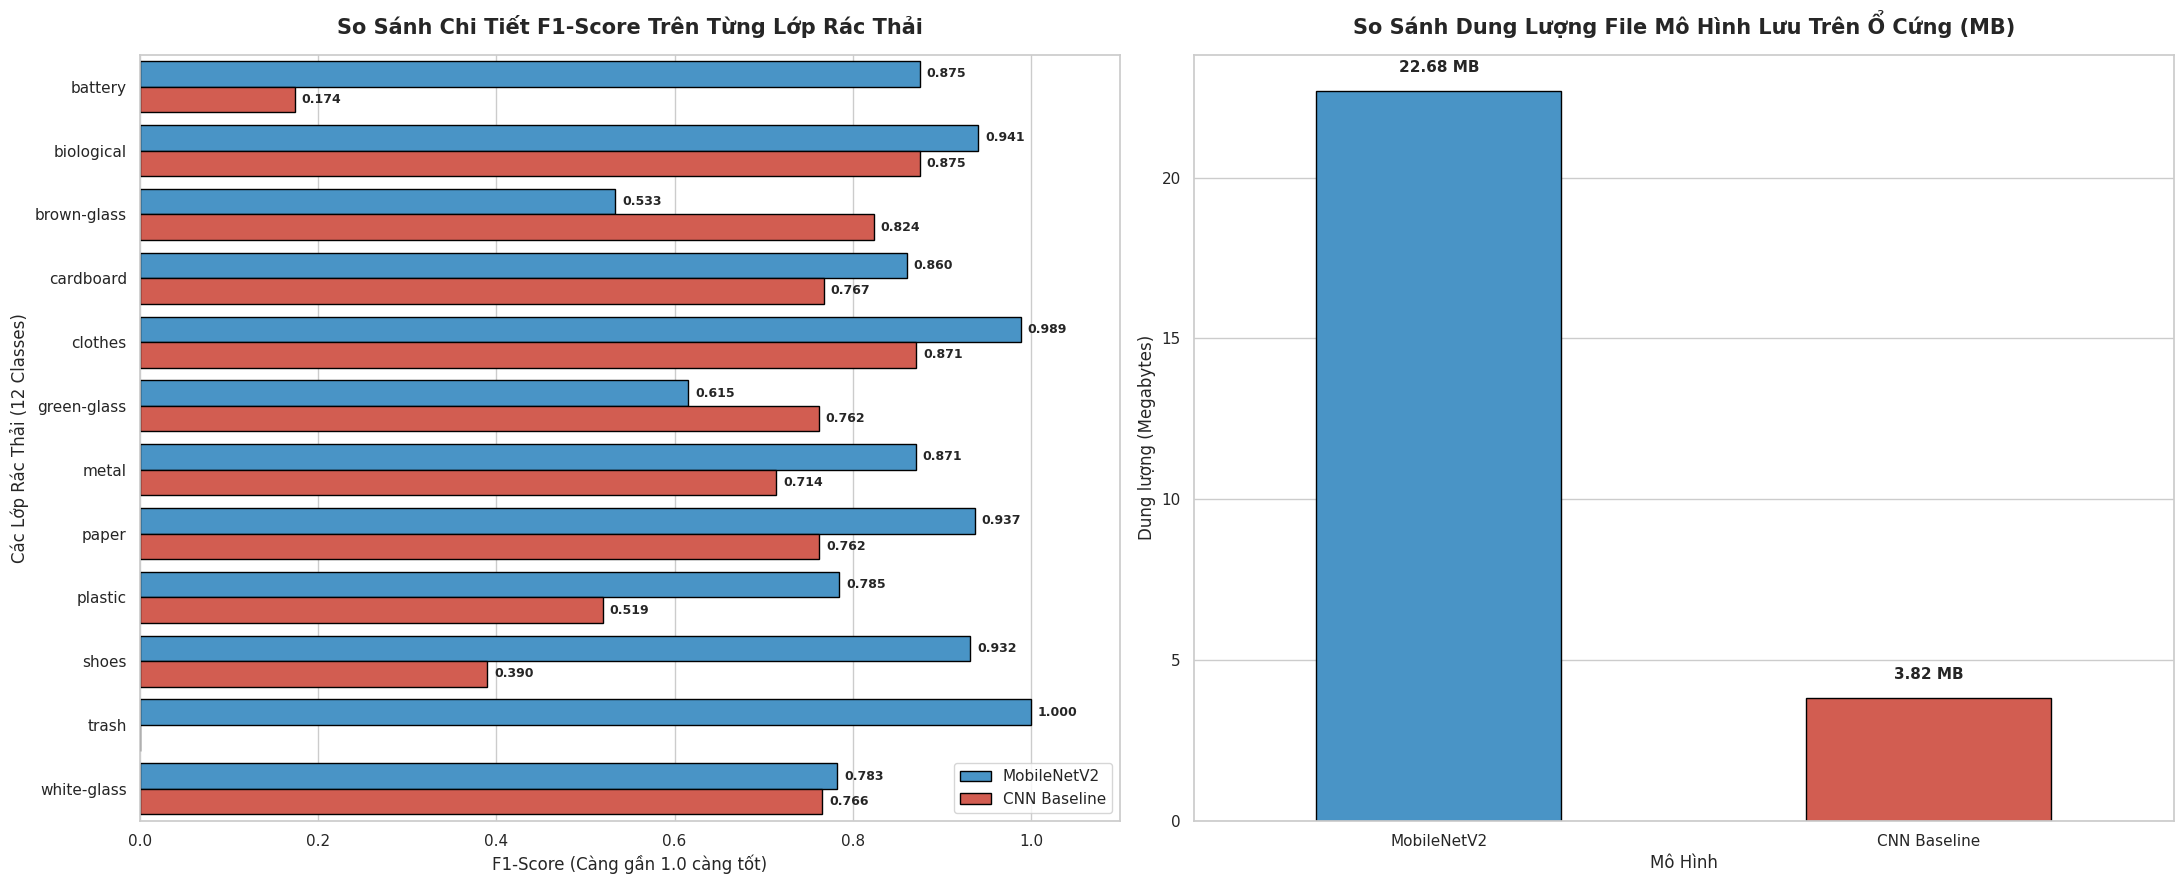

📊 PHÂN TÍCH TÀI NGUYÊN:
 - MobileNetV2:  22.68 MB
 - CNN Baseline: 3.82 MB


In [22]:
# --- BIỂU ĐỒ 1: SO SÁNH F1-SCORE TỪNG LỚP RÁC ---
# Lấy báo cáo chi tiết dạng dictionary từ kết quả test trước đó
report_mnet = classification_report(
    mobilenet_results["y_true"], mobilenet_results["y_pred"],
    target_names=class_names, output_dict=True
)
report_cnn = classification_report(
    cnn_results["y_true"], cnn_results["y_pred"],
    target_names=class_names, output_dict=True
)

# Trích xuất F1-Score của từng class
class_f1_data = []
for c_name in class_names:
    class_f1_data.append({
        "Lớp Rác": c_name,
        "MobileNetV2": report_mnet[c_name]["f1-score"],
        "CNN Baseline": report_cnn[c_name]["f1-score"]
    })

df_class_f1 = pd.DataFrame(class_f1_data)
df_class_f1_melted = pd.melt(
    df_class_f1, id_vars=["Lớp Rác"], var_name="Mô hình", value_name="F1-Score"
)

# Tiến hành vẽ biểu đồ cột nằm ngang so sánh 12 lớp
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=df_class_f1_melted,
    y="Lớp Rác", x="F1-Score", hue="Mô hình",
    palette=["#3498db", "#e74c3c"], ax=ax1, edgecolor="black", linewidth=1
)
ax1.set_title("So Sánh Chi Tiết F1-Score Trên Từng Lớp Rác Thải", fontsize=15, fontweight="bold", pad=15)
ax1.set_xlabel("F1-Score (Càng gần 1.0 càng tốt)", fontsize=12)
ax1.set_ylabel("Các Lớp Rác Thải (12 Classes)", fontsize=12)
ax1.set_xlim(0, 1.1)
ax1.legend(loc="lower right")

# Hiển thị số liệu trực tiếp trên đầu mỗi cột ngang
for p in ax1.patches:
    width = p.get_width()
    if width > 0:
        ax1.annotate(
            f"{width:.3f}",
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=9, fontweight='bold'
        )

# --- BIỂU ĐỒ 2: SO SÁNH DUNG LƯỢNG MÔ HÌNH (MB) ---
# Tính dung lượng thực tế của file model trên ổ cứng
mnet_size_mb = os.path.getsize(FINAL_MODEL_PATH) / (1024 * 1024)
cnn_size_mb = os.path.getsize(CNN_FINAL_MODEL_PATH) / (1024 * 1024)

df_size = pd.DataFrame({
    "Mô hình": ["MobileNetV2", "CNN Baseline"],
    "Dung lượng (MB)": [mnet_size_mb, cnn_size_mb]
})

sns.barplot(
    data=df_size,
    x="Mô hình", y="Dung lượng (MB)",
    palette=["#3498db", "#e74c3c"], ax=ax2, edgecolor="black", linewidth=1, width=0.5
)
ax2.set_title("So Sánh Dung Lượng File Mô Hình Lưu Trên Ổ Cứng (MB)", fontsize=15, fontweight="bold", pad=15)
ax2.set_xlabel("Mô Hình", fontsize=12)
ax2.set_ylabel("Dung lượng (Megabytes)", fontsize=12)

# Hiển thị số dung lượng cụ thể lên đầu cột
for p in ax2.patches:
    height = p.get_height()
    ax2.text(
        p.get_x() + p.get_width() / 2., height + 0.5,
        f"{height:.2f} MB",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig("models/deep_comparison_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# In ra phân tích nhanh
print(f"📊 PHÂN TÍCH TÀI NGUYÊN:")
print(f" - MobileNetV2:  {mnet_size_mb:.2f} MB")
print(f" - CNN Baseline: {cnn_size_mb:.2f} MB")


## 10. Dự Đoán Ảnh Mẫu Ngoài Thực Tế & Vẽ Biểu Đồ Xác Suất
*   Cung cấp các hàm dự đoán và xử lý ảnh lẻ ngoài hệ thống.
*   Chạy thử dự đoán trên 5 ảnh ngẫu nhiên lấy trực tiếp từ tập Test, vẽ đồ thị phân phối độ tự tin (Confidence score) Top 3 nhãn khả thi nhất.


TIẾN HÀNH THỬ NGHIỆM THỰC TẾ TRÊN 5 ẢNH TẬP TEST:


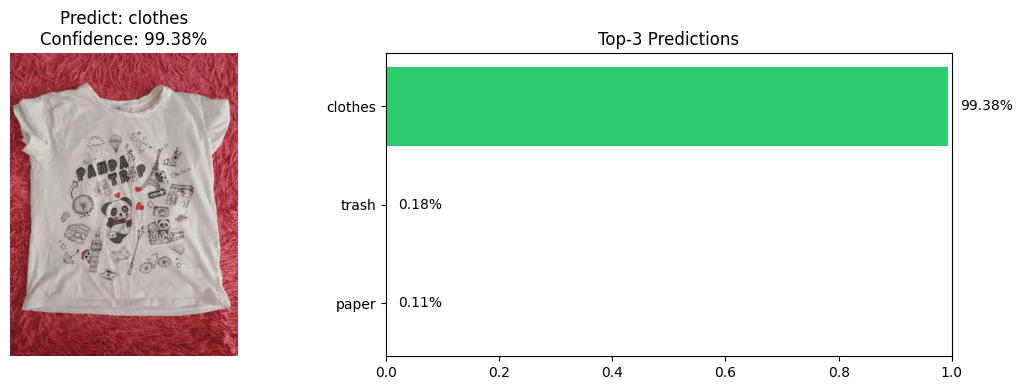

[✅ ĐÚNG] Thật: clothes | Dự đoán: clothes (99.38%)



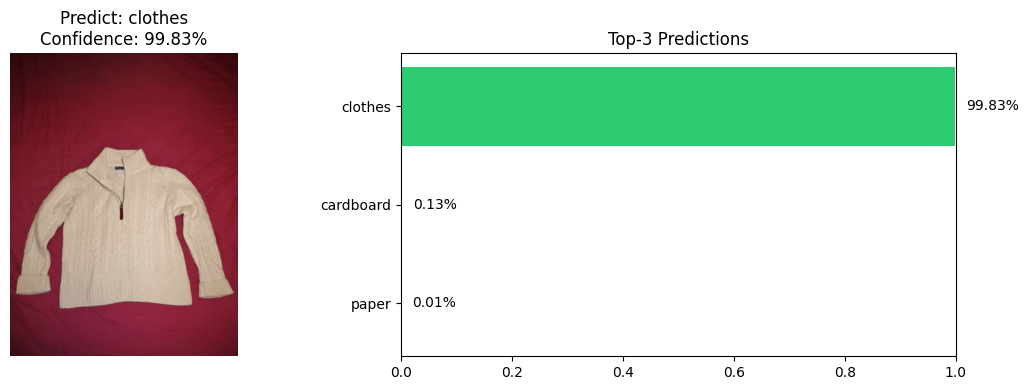

[✅ ĐÚNG] Thật: clothes | Dự đoán: clothes (99.83%)



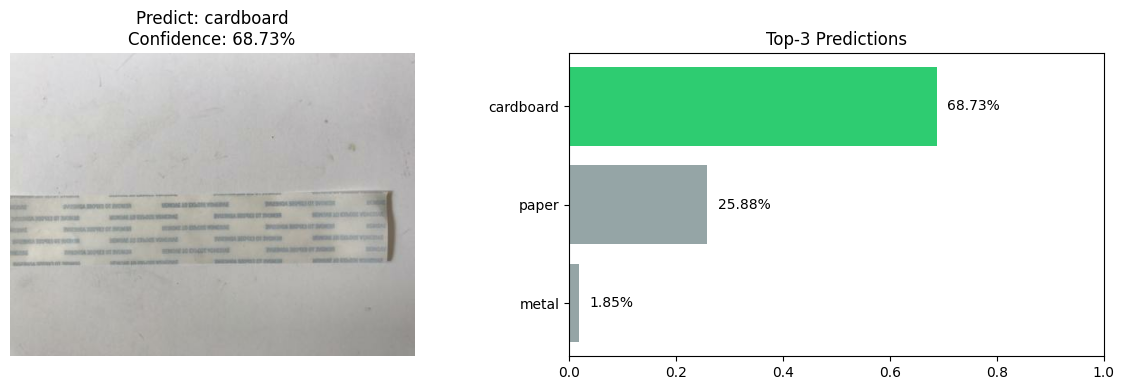

[❌ SAI] Thật: paper | Dự đoán: cardboard (68.73%)



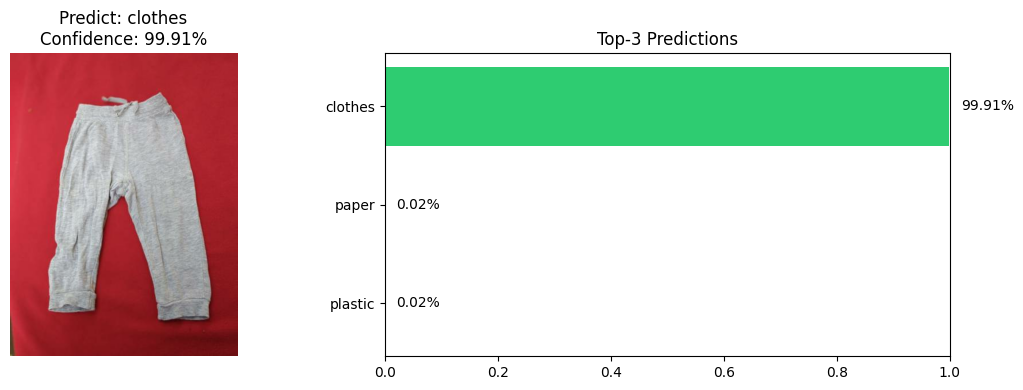

[✅ ĐÚNG] Thật: clothes | Dự đoán: clothes (99.91%)



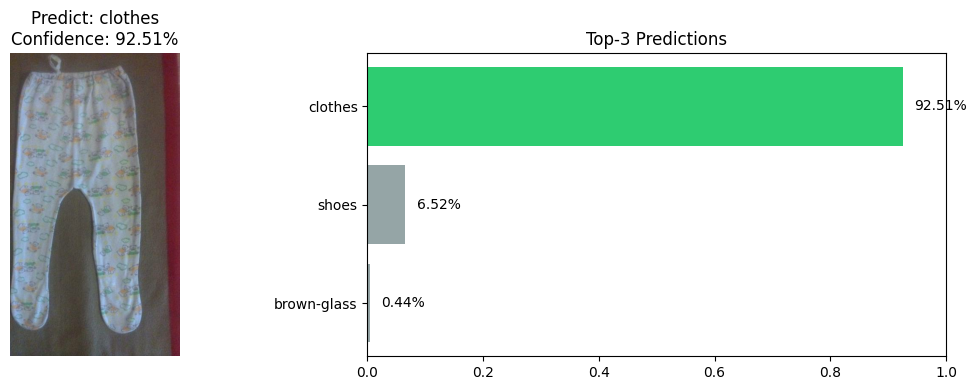

[✅ ĐÚNG] Thật: clothes | Dự đoán: clothes (92.51%)



In [19]:
def predict_single_image(model, image_path, class_names, image_size=IMAGE_SIZE, preprocessing=MODEL_PREPROCESSING):
    """Xử lý ảnh lẻ đầu vào và trả về Top 3 phân loại tự tin nhất."""
    raw = tf.io.read_file(str(image_path))
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, image_size, method="bilinear")
    image.set_shape((image_size[0], image_size[1], 3))

    if preprocessing == "mobilenet_v2":
        image = image * 2.0 - 1.0  # scale pixel [-1, 1]

    image_batch = tf.expand_dims(image, axis=0)
    probs = model.predict(image_batch, verbose=0)[0]

    top3_indices = np.argsort(probs)[::-1][:3]
    top3 = [(class_names[i], float(probs[i])) for i in top3_indices]

    return {
        "image_path": str(image_path),
        "predicted_class": class_names[top3_indices[0]],
        "confidence": float(probs[top3_indices[0]]),
        "top3_predictions": top3,
    }

def predict_and_show(model, image_path, class_names, **kwargs):
    """Vẽ ảnh mẫu và đồ thị thanh thể hiện độ tự tin."""
    result = predict_single_image(model, image_path, class_names, **kwargs)
    raw = tf.io.read_file(str(image_path))
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))
    ax_img.imshow(img.numpy())
    ax_img.set_title(f"Predict: {result['predicted_class']}\nConfidence: {result['confidence']:.2%}")
    ax_img.axis("off")

    top3 = result["top3_predictions"]
    names = [t[0] for t in top3][::-1]
    scores = [t[1] for t in top3][::-1]
    colors = ["#2ecc71" if i == 2 else "#95a5a6" for i in range(3)]

    ax_bar.barh(names, scores, color=colors)
    ax_bar.set_xlim(0, 1)
    ax_bar.set_title("Top-3 Predictions")
    for i, score in enumerate(scores):
        ax_bar.text(score + 0.02, i, f"{score:.2%}", va="center")

    plt.tight_layout()
    plt.show()
    return result

# Chạy thử nghiệm ngẫu nhiên 5 ảnh mẫu
sample_images = test_df.sample(n=min(5, len(test_df)), random_state=SEED)
print("TIẾN HÀNH THỬ NGHIỆM THỰC TẾ TRÊN 5 ẢNH TẬP TEST:")
for _, row in sample_images.iterrows():
    res = predict_and_show(best_mobilenet, row["image_path"], class_names)
    status = "✅ ĐÚNG" if row["label"] == res["predicted_class"] else "❌ SAI"
    print(f"[{status}] Thật: {row['label']} | Dự đoán: {res['predicted_class']} ({res['confidence']:.2%})\n")


## 11. Lưu Ánh Xạ Label Mapping & Cấu Hình Phục Vụ Triển Khai Web App
*   Lưu ánh xạ ID-nhãn dạng JSON (`label_mapping.json`) - đây là file bắt buộc phải nạp lên Web App (Streamlit, Flask, React...) để giải mã lớp dự đoán đầu ra.
*   Lưu các báo cáo kiểm thử classification report và model configs thành file tĩnh trong thư mục `models/` để lưu giữ tài liệu thí nghiệm.


In [20]:
# 1. Lưu ánh xạ label_mapping.json
LABEL_MAPPING_PATH = MODEL_DIR / "label_mapping.json"
label_mapping = {int(idx): class_name for idx, class_name in enumerate(class_names)}
with open(LABEL_MAPPING_PATH, "w", encoding="utf-8") as file:
    json.dump(label_mapping, file, ensure_ascii=False, indent=2)

# 2. Lưu MobileNetV2 config metadata
with open(MODEL_DIR / "mobilenetv2_config.json", "w", encoding="utf-8") as file:
    json.dump({
        "image_size": list(IMAGE_SIZE),
        "num_classes": int(num_classes),
        "model_preprocessing": MODEL_PREPROCESSING,
        "class_names": class_names,
        "test_accuracy": float(mobilenet_results["accuracy"]),
        "test_macro_f1": float(mobilenet_results["macro_f1"])
    }, file, ensure_ascii=False, indent=2)

# 3. Lưu CNN config metadata
with open(MODEL_DIR / "cnn_config.json", "w", encoding="utf-8") as file:
    json.dump({
        "image_size": list(IMAGE_SIZE),
        "num_classes": int(num_classes),
        "model_preprocessing": "rescale_0_1",
        "class_names": class_names,
        "test_accuracy": float(cnn_results["accuracy"]),
        "test_macro_f1": float(cnn_results["macro_f1"])
    }, file, ensure_ascii=False, indent=2)

# 4. Lưu báo cáo chi tiết classification report
for tag, res in [("mobilenetv2", mobilenet_results), ("cnn", cnn_results)]:
    report_dict = classification_report(
        res["y_true"], res["y_pred"], target_names=class_names, digits=4, output_dict=True
    )
    with open(MODEL_DIR / f"{tag}_classification_report.json", "w", encoding="utf-8") as file:
        json.dump(report_dict, file, ensure_ascii=False, indent=2)

print("TẤT CẢ METADATA VÀ CHECKPOINTS ĐÃ ĐƯỢC LƯU HOÀN THÀNH TẠI THƯ MỤC 'models/'!")


TẤT CẢ METADATA VÀ CHECKPOINTS ĐÃ ĐƯỢC LƯU HOÀN THÀNH TẠI THƯ MỤC 'models/'!


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
